# HyDesign Electrolyser (P2X) Model — Tests & Visualisations

Demonstrates the 5 core capabilities of the HyDesign P2X electrolyser model.

## Inputs
| Variable | Units | Typical value | Description |
|---|---|---|---|
| `ptg_MW` | MW | 50–500 | Electrolyser rated power |
| `HSS_kg` | kg | 500–10 000 | Hydrogen storage capacity |
| `eff_curve` | [(load, H2)] | from CSV | Piecewise-linear production curve |
| `price_H2` | EUR/kg | 5 | H2 selling price |
| `storage_eff` | — | 0.9 | Compressor round-trip efficiency |
| `hhv` | kWh/kg | 39.3 | Higher heating value of H2 |
| `wind_t` | MW | time series | Wind power supply |
| `price_t` | EUR/MWh | time series | Electricity spot price |
| `m_H2_demand_t` | kg/h | time series | H2 demand |
| `E_batt_MWh_t` | MWh | time series | Battery energy capacity |

## Outputs
| Variable | Units | Description |
|---|---|---|
| `P_ptg_t` | MW | Electrolyser power consumption |
| `m_H2_t` | kg/h | Hydrogen production rate |
| `m_H2_offtake_t` | kg/h | Hydrogen offtake / sold |
| `LoS_H2_t` | kg | H2 storage level |
| `CAPEX_ptg` | EUR | Total capital cost |
| `OPEX_ptg` | EUR/yr | Annual O&M cost |

## Capabilities shown
1. **Efficiency curves** — PEM vs Alkaline (efficiency % and production kg/h/MW)
2. **Greedy H2 production** — wind to electrolyser with no optimisation
3. **EMS dispatch optimisation** — 1-week CPLEX MILP (wind + battery + H2)
4. **Cost model** — CAPEX/OPEX breakdown + LCOH sensitivity
5. **Annual economics** — full-year EMS, H2 yield, capacity factor, LCOH

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from docplex.mp.model import Model
from hydesign.examples import examples_filepath

# Wind helper (mirrors hydesign/wind/wind.py)
def get_wind_ts(ws, pcw, wst, wpp_efficiency=0.95):
    return wpp_efficiency * np.interp(wst, ws, pcw, left=0, right=0)

# Efficiency-curve loader
def load_eff_curve(curve_name):
    fn = examples_filepath + 'Europe/Electrolyzer_efficiency_curves.csv'
    df = pd.read_csv(fn)
    col_no = df.columns.get_loc(curve_name)
    my_df = df.iloc[:, col_no:col_no + 2].dropna()
    return my_df[1:].values.astype(float)   # skip header row

# EMS helpers (mirrors hydesign/ems/ems.py)
def split_in_batch(array, N):
    batch, counter = [], 0
    while counter * N < len(array):
        end = min((counter + 1) * N, len(array))
        batch.append(array[counter * N:end])
        counter += 1
    return batch

def expand_to_lifetime(x, life_y=25, intervals_per_hour=1, life=None):
    if life is None:
        life = life_y * 365 * 24 * intervals_per_hour
    return np.tile(x, int(np.ceil(life / len(x))))[:life]

# Single-batch CPLEX EMS (mirrors hydesign/ems/ems_P2X.py :: ems_cplex_parts_P2X)
def ems_cplex_parts_P2X(
    wind_ts, solar_ts, price_ts, P_batt_MW, E_batt_MWh_t, hpp_grid_connection,
    battery_depth_of_discharge, charge_efficiency, price_H2, ptg_MW, HSS_kg,
    storage_eff, hhv, m_H2_demand_ts, H2_storage_t, penalty_factor_H2,
    eff_curve, min_power_standby, load_min_penalty_factor=1e6,
    peak_hr_quantile=0.9, cost_of_battery_P_fluct_in_peak_price_ratio=0.5,
    n_full_power_hours_expected_per_day_at_peak_price=3,
    electrolyzer_eff_curve_type='production',
):
    N_t = len(price_ts.index)
    N_days = N_t / 24
    e_peak_day_expected = n_full_power_hours_expected_per_day_at_peak_price * hpp_grid_connection
    e_peak_period_expected = e_peak_day_expected * N_days
    price_peak = np.quantile(price_ts.values, peak_hr_quantile)
    peak_hours_index = np.where(price_ts >= price_peak)[0]

    price_ts_to_max = price_peak - price_ts
    price_ts_to_max.loc[price_ts_to_max < 0] = 0
    price_ts_to_max.iloc[:-1] = (
        0.5 * price_ts_to_max.iloc[:-1].values + 0.5 * price_ts_to_max.iloc[1:].values
    )

    mdl = Model(name='EMS')
    mdl.context.cplex_parameters.threads = 1
    mdl.context.cplex_parameters.emphasis.mip = 1

    time = price_ts.index
    SOCtime = time.append(pd.Index([time[-1] + pd.Timedelta('1hour')]))

    P_HPP_t   = mdl.continuous_var_dict(time, lb=0, ub=hpp_grid_connection, name='HPP power output')
    P_curt_t  = mdl.continuous_var_dict(time, lb=0, name='Curtailment')
    P_cd_t    = mdl.continuous_var_dict(time,
                    lb=-P_batt_MW / charge_efficiency,
                    ub=P_batt_MW * charge_efficiency, name='Battery power')
    E_SOC_t   = mdl.continuous_var_dict(SOCtime, lb=0, name='Energy level')
    LoS_H2_t  = mdl.continuous_var_dict(SOCtime, lb=0, name='H2 storage level')
    P_ptg_t   = mdl.continuous_var_dict(time,
                    lb=min_power_standby * ptg_MW, ub=ptg_MW, name='P2G power')
    m_H2_t    = mdl.continuous_var_dict(time, lb=0, name='H2 produced')
    m_offtake = mdl.continuous_var_dict(time, lb=0, name='H2 offtake')
    penalty   = mdl.continuous_var(name='penalty', lb=-1e12)
    e_pen     = mdl.continuous_var(name='e_penalty', lb=-1e12)

    # fabs battery fluctuation term removed (exceeds CPLEX Community Edition var limit)
    f1   = mdl.piecewise(0, [(0, 0)], 1)
    f2   = mdl.piecewise(charge_efficiency, [(0, 0)], 1 / charge_efficiency)
    f3   = mdl.piecewise(1 / storage_eff,   [(0, 0)], storage_eff)

    if electrolyzer_eff_curve_type == 'production':
        H2_curve = [(l * ptg_MW, h * ptg_MW) for l, h in eff_curve]
    else:
        H2_curve = [(l * ptg_MW, l * ptg_MW * e / hhv * 1000) for l, e in eff_curve]
    H2_prod = mdl.piecewise(0, H2_curve, 0)

    mdl.add_constraint(e_pen == (
        e_peak_period_expected - mdl.sum(P_HPP_t[time[i]] for i in peak_hours_index)))
    mdl.add_constraint(penalty == price_peak * f1(e_pen) +
        mdl.sum(penalty_factor_H2 * (m_H2_demand_ts[t] - m_offtake[t]) for t in time))
    mdl.add_constraint(E_SOC_t[SOCtime[0]]  == 0.5 * E_batt_MWh_t[time[0]])
    mdl.add_constraint(E_SOC_t[SOCtime[-1]] == 0.5 * E_batt_MWh_t[time[0]])
    mdl.add_constraint(LoS_H2_t[SOCtime[0]]  == 0)
    mdl.add_constraint(LoS_H2_t[SOCtime[-1]] == 0)

    mdl.maximize(
        mdl.sum(price_ts[t] * P_HPP_t[t] + price_H2 * m_offtake[t] for t in time)
        - penalty
    )

    for t in time:
        tt = t + pd.Timedelta('1hour')
        mdl.add_constraint(P_HPP_t[t] == wind_ts[t] + solar_ts[t]
                           - P_curt_t[t] + P_cd_t[t] - P_ptg_t[t])
        mdl.add_constraint(E_SOC_t[tt] == E_SOC_t[t] - f2(P_cd_t[t]))
        mdl.add_constraint(LoS_H2_t[tt] == LoS_H2_t[t] + f3(m_H2_t[t] - m_offtake[t]))
        mdl.add_constraint(E_SOC_t[t] >= (1 - battery_depth_of_discharge) * E_batt_MWh_t[t])
        mdl.add_constraint(E_SOC_t[t] <= E_batt_MWh_t[t])
        mdl.add_constraint(P_cd_t[t] <= P_batt_MW * charge_efficiency)
        mdl.add_constraint(P_cd_t[t] >= -P_batt_MW / charge_efficiency)
        mdl.add_constraint(LoS_H2_t[t] <= H2_storage_t[t])
        mdl.add_constraint(m_offtake[t] <= m_H2_demand_ts[t])
        if H2_storage_t[t] == 0:
            m_offtake[t] = m_H2_t[t]
        mdl.add_constraint(m_H2_t[t] == H2_prod(P_ptg_t[t]))

    sol = mdl.solve(log_output=False)

    def _get(var_dict, idx):
        df = pd.DataFrame.from_dict(sol.get_value_dict(var_dict), orient='index').loc[:, 0]
        return df.reindex(idx, fill_value=0).to_numpy(copy=True)

    P_HPP  = _get(P_HPP_t, time)
    P_curt = _get(P_curt_t, time)
    P_cd   = _get(P_cd_t, time)
    E_SOC  = _get(E_SOC_t, SOCtime)
    P_ptg  = _get(P_ptg_t, time)
    m_H2   = _get(m_H2_t, time)
    m_off  = _get(m_offtake, time)
    LoS_H2 = _get(LoS_H2_t, time)
    pen_val = sol.get_value(penalty)
    P_ptg_SB = np.zeros_like(P_ptg)
    for t_i in range(N_t):
        if abs(P_ptg[t_i] - min_power_standby * ptg_MW) < 1e-6:
            P_ptg_SB[t_i] = P_ptg[t_i]; P_ptg[t_i] = 0; m_H2[t_i] = 0
    mdl.end()
    return P_HPP, P_curt, P_cd, P_ptg, P_ptg_SB, E_SOC, m_H2, m_off, LoS_H2, np.ones(N_t) * pen_val / N_t

def ems_cplex_P2X(
    wind_ts, solar_ts, price_ts, P_batt_MW, E_batt_MWh_t, hpp_grid_connection,
    battery_depth_of_discharge, charge_efficiency, price_H2, ptg_MW, HSS_kg,
    storage_eff, hhv, m_H2_demand_ts, H2_storage_t, penalty_factor_H2,
    eff_curve, min_power_standby, batch_size=62,
    electrolyzer_eff_curve_type='production', **kwargs
):
    batches = split_in_batch(list(range(len(wind_ts))), batch_size)
    N = len(wind_ts)
    P_HPP=np.zeros(N); P_curt=np.zeros(N); P_cd=np.zeros(N)
    P_ptg=np.zeros(N); P_ptg_SB=np.zeros(N); m_H2=np.zeros(N)
    m_off=np.zeros(N); LoS_H2=np.zeros(N); E_SOC=np.zeros(N+1); pen=np.zeros(N)
    for batch in batches:
        res = ems_cplex_parts_P2X(
            wind_ts=wind_ts.iloc[batch], solar_ts=solar_ts.iloc[batch],
            price_ts=price_ts.iloc[batch], P_batt_MW=P_batt_MW,
            E_batt_MWh_t=E_batt_MWh_t.iloc[batch], hpp_grid_connection=hpp_grid_connection,
            battery_depth_of_discharge=battery_depth_of_discharge, charge_efficiency=charge_efficiency,
            price_H2=price_H2, ptg_MW=ptg_MW, HSS_kg=HSS_kg, storage_eff=storage_eff, hhv=hhv,
            m_H2_demand_ts=m_H2_demand_ts.iloc[batch], H2_storage_t=H2_storage_t.iloc[batch],
            penalty_factor_H2=penalty_factor_H2, eff_curve=eff_curve, min_power_standby=min_power_standby,
            electrolyzer_eff_curve_type=electrolyzer_eff_curve_type, **kwargs)
        P_HPP[batch]=res[0]; P_curt[batch]=res[1]; P_cd[batch]=res[2]
        P_ptg[batch]=res[3]; P_ptg_SB[batch]=res[4]; E_SOC[batch]=res[5][:-1]
        m_H2[batch]=res[6]; m_off[batch]=res[7]; LoS_H2[batch]=res[8]; pen[batch]=res[9]
    return P_HPP, P_curt, P_cd, P_ptg, P_ptg_SB, E_SOC, m_H2, m_off, LoS_H2, pen

# Cost model (mirrors hydesign/costs/costs.py :: ptg_cost)
class ptg_cost:
    def __init__(self, electrolyzer_capex_cost, electrolyzer_opex_cost,
                 electrolyzer_power_electronics_cost, water_cost, water_treatment_cost,
                 water_consumption, storage_capex_cost, storage_opex_cost,
                 transportation_cost, transportation_distance, N_time, life_y=25):
        self.elz_capex = electrolyzer_capex_cost
        self.elz_opex  = electrolyzer_opex_cost
        self.elz_pe    = electrolyzer_power_electronics_cost
        self.wc  = water_cost;  self.wtc = water_treatment_cost
        self.wcons = water_consumption
        self.s_capex = storage_capex_cost; self.s_opex = storage_opex_cost
        self.tc = transportation_cost;     self.td = transportation_distance
        self.yearly_h = 365 * 24; self.life_y = life_y

    def compute(self, ptg_MW, HSS_kg, m_H2_offtake_t):
        annual_H2 = m_H2_offtake_t.mean() * self.yearly_h
        CAPEX = (ptg_MW * (self.elz_capex + self.elz_pe)
                 + self.s_capex * HSS_kg
                 + annual_H2 * self.tc * self.td)
        OPEX  = ptg_MW * self.elz_opex + self.s_opex * HSS_kg
        water = annual_H2 * self.wcons * (self.wc + self.wtc) / 1000
        return CAPEX, OPEX, water

print('All imports and inline functions OK')

All imports and inline functions OK


## Capability 1 — Electrolyser Efficiency Curves

Two technologies are available:

| Technology | `eff_curve_type` | CSV column |
|---|---|---|
| PEM | `"efficiency"` | `"PEM electrolyzer"` |
| Alkaline | `"efficiency"` | `"Alkaline electrolyzer"` |
| PEM | `"production"` | `"PEM electrolyzer H2 production"` |
| Alkaline | `"production"` | `"Alkaline electrolyzer H2 production"` |

**Efficiency** curves = ratio of H2 chemical energy (HHV) to electrical input.
**Production** curves = kg H2 per hour per MW installed as a function of normalised load.

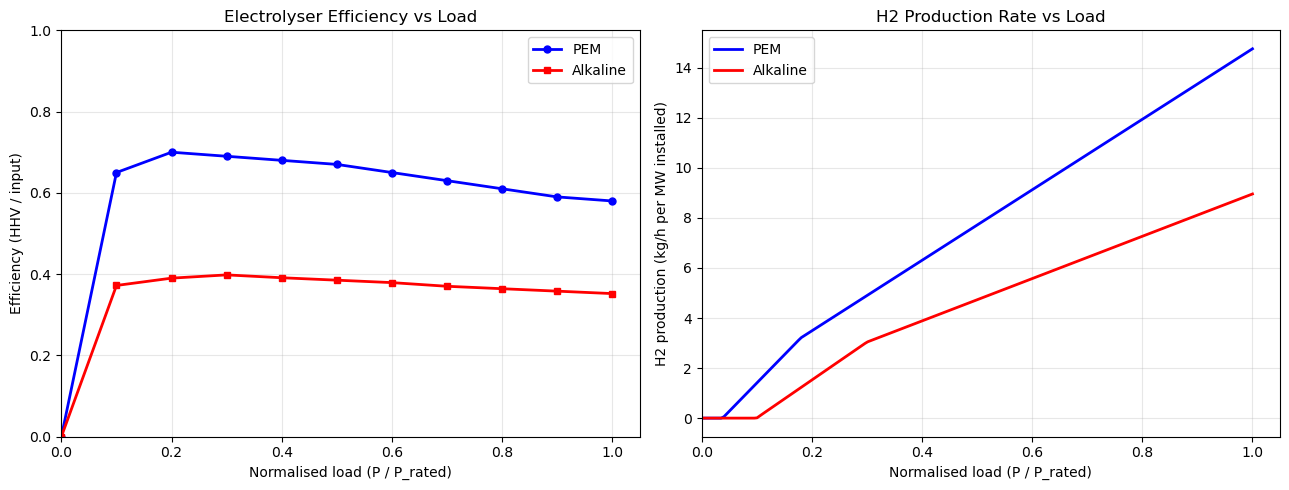

At full load, 100 MW PEM      -> 1475.8 kg H2/h
At full load, 100 MW Alkaline -> 895.7 kg H2/h
PEM peak efficiency  : 58.0 %
Alkaline peak eff.   : 35.2 %


In [2]:
hhv = 39.3  # kWh/kg — Higher Heating Value of hydrogen (energy content per kg)

# Load PEM and Alkaline efficiency curves [load_fraction, efficiency_HHV]
pem_eff  = load_eff_curve('PEM electrolyzer')
alk_eff  = load_eff_curve('Alkaline electrolyzer')
# Load production curves [load_fraction, kg_H2/h per MW_installed]
pem_prod = load_eff_curve('PEM electrolyzer H2 production')
alk_prod = load_eff_curve('Alkaline electrolyzer H2 production')

# Dense load axis for smooth curves (200 points 0→1)
load_fine = np.linspace(0, 1, 200)
# Interpolate H2 production rate at each load; 0 outside curve range
pem_h2 = np.interp(load_fine, pem_prod[:-1, 0], pem_prod[:-1, 1], left=0, right=0)
alk_h2 = np.interp(load_fine, alk_prod[:-1, 0], alk_prod[:-1, 1], left=0, right=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: efficiency (HHV ratio) vs normalised load
axes[0].plot(pem_eff[:, 0], pem_eff[:, 1], 'b-o', lw=2, ms=5, label='PEM')
axes[0].plot(alk_eff[:, 0], alk_eff[:, 1], 'r-s', lw=2, ms=5, label='Alkaline')
axes[0].set_xlabel('Normalised load (P / P_rated)')
axes[0].set_ylabel('Efficiency (HHV / input)')
axes[0].set_title('Electrolyser Efficiency vs Load')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xlim(0, 1.05); axes[0].set_ylim(0, 1)

# Right: H2 production rate [kg/h per MW] vs normalised load
axes[1].plot(load_fine, pem_h2, 'b-', lw=2, label='PEM')
axes[1].plot(load_fine, alk_h2, 'r-', lw=2, label='Alkaline')
axes[1].set_xlabel('Normalised load (P / P_rated)')
axes[1].set_ylabel('H2 production (kg/h per MW installed)')
axes[1].set_title('H2 Production Rate vs Load')
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_xlim(0, 1.05)

plt.tight_layout(); plt.show()

# Reference 100 MW system — max H2 at full load
ptg_ref = 100.0
max_pem = float(np.interp(1.0, pem_prod[:-1, 0], pem_prod[:-1, 1])) * ptg_ref  # kg/h
max_alk = float(np.interp(1.0, alk_prod[:-1, 0], alk_prod[:-1, 1])) * ptg_ref
print(f'At full load, {ptg_ref:.0f} MW PEM      -> {max_pem:.1f} kg H2/h')
print(f'At full load, {ptg_ref:.0f} MW Alkaline -> {max_alk:.1f} kg H2/h')
print(f'PEM peak efficiency  : {pem_eff[-1, 1]*100:.1f} %')
print(f'Alkaline peak eff.   : {alk_eff[-1, 1]*100:.1f} %')

## Capability 2 — Greedy H2 Production (No Optimisation)

Simplest operation: all available wind power fed directly to the electrolyser up to `ptg_MW`.
H2 production at each timestep is read from the piecewise-linear production curve.

This gives the **upper bound** on H2 output — no grid sales, no battery, no demand shaping.

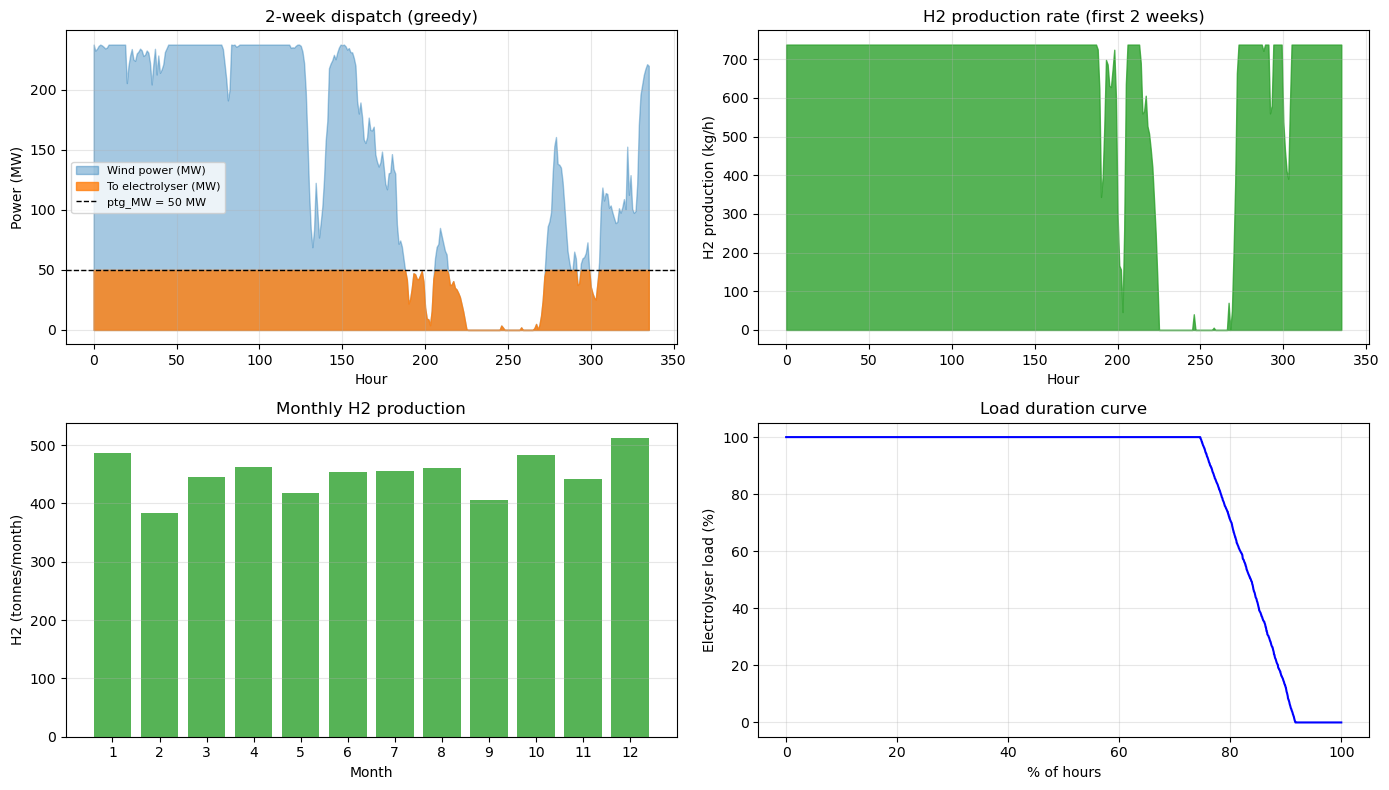

Annual H2 production (greedy) : 5410 tonnes/yr
Electrolyser capacity factor  : 83.7 %
Curtailed wind energy         : 752478 MWh/yr


In [3]:
# Load France hourly weather CSV: wind speed, direction, electricity price, temperature
weather = pd.read_csv(
    examples_filepath + 'Europe/GWA2/input_ts_France_good_wind.csv',
    index_col=0, parse_dates=True)
wst = weather.WS_150.values  # wind speed at 150m hub height [m/s], 8760 values

# Generic piecewise-linear power curve (normalised 0-1); cut-in 3 m/s, rated 12 m/s, cut-out 26 m/s
ws_ref = np.array([0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 25, 26])
pc_ref = np.array([0, 0, 0.08, 0.18, 0.3, 0.45, 0.62, 0.78, 0.90, 0.97, 1.0, 1.0, 1.0, 0])

ptg_MW  = 50.0   # MW — electrolyser rated power
wind_MW = 250.0  # MW — wind farm rated power (larger than ptg_MW to force curtailment)
HSS_kg  = 2000.0 # kg — hydrogen storage tank capacity

# Compute hourly wind farm power [MW] from wind speed time series
wind_t = get_wind_ts(ws_ref, pc_ref * wind_MW, wst, wpp_efficiency=0.95)

# Greedy: send all wind to electrolyser up to rated; excess curtailed
P_in   = np.minimum(wind_t, ptg_MW)   # power into electrolyser [MW]
load   = P_in / ptg_MW                # normalised load fraction 0-1
# Look up H2 production [kg/h per MW] from PEM curve, scale to full electrolyser
m_H2_t = np.interp(load, pem_prod[:-1, 0], pem_prod[:-1, 1], left=0, right=0) * ptg_MW

# Aggregate to monthly H2 totals [tonnes/month]
m_H2_series = pd.Series(m_H2_t, index=weather.index)
monthly_H2  = m_H2_series.resample('ME').sum() / 1000   # tonnes/month

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

t2w = slice(0, 24 * 14)  # first 2 weeks = 336 hours
# Top-left: wind available vs power to electrolyser; gap = curtailment
axes[0, 0].fill_between(range(24*14), wind_t[t2w], alpha=0.4, color='tab:blue', label='Wind power (MW)')
axes[0, 0].fill_between(range(24*14), P_in[t2w],   alpha=0.8, color='tab:orange', label='To electrolyser (MW)')
axes[0, 0].axhline(ptg_MW, color='k', ls='--', lw=1, label=f'ptg_MW = {ptg_MW:.0f} MW')
axes[0, 0].set_xlabel('Hour'); axes[0, 0].set_ylabel('Power (MW)')
axes[0, 0].set_title('2-week dispatch (greedy)'); axes[0, 0].legend(fontsize=8); axes[0, 0].grid(alpha=0.3)

# Top-right: H2 production rate [kg/h] — mirrors P_in shape via efficiency curve
axes[0, 1].fill_between(range(24*14), m_H2_t[t2w], color='tab:green', alpha=0.8)
axes[0, 1].set_xlabel('Hour'); axes[0, 1].set_ylabel('H2 production (kg/h)')
axes[0, 1].set_title('H2 production rate (first 2 weeks)'); axes[0, 1].grid(alpha=0.3)

# Bottom-left: monthly totals show seasonal wind pattern (France: more in winter)
axes[1, 0].bar(range(1, 13), monthly_H2.values, color='tab:green', alpha=0.8)
axes[1, 0].set_xlabel('Month'); axes[1, 0].set_ylabel('H2 (tonnes/month)')
axes[1, 0].set_title('Monthly H2 production'); axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].grid(axis='y', alpha=0.3)

# Bottom-right: load duration curve — fraction of hours at each load level
sorted_load = np.sort(load)[::-1]  # sort descending (highest load hours first)
axes[1, 1].plot(np.linspace(0, 100, len(sorted_load)), sorted_load * 100, 'b-', lw=1.5)
axes[1, 1].set_xlabel('% of hours'); axes[1, 1].set_ylabel('Electrolyser load (%)')
axes[1, 1].set_title('Load duration curve'); axes[1, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

annual_H2_t = m_H2_t.sum() / 1000  # total annual H2 [tonnes/yr]
cf = m_H2_t.mean() / (pem_prod[3, 1] * ptg_MW)  # capacity factor vs full-load production
print(f'Annual H2 production (greedy) : {annual_H2_t:.0f} tonnes/yr')
print(f'Electrolyser capacity factor  : {cf*100:.1f} %')
print(f'Curtailed wind energy         : {(wind_t - P_in).sum():.0f} MWh/yr')

## Capability 3 — EMS Dispatch Optimisation (CPLEX MILP)

The `ems_cplex_P2X` solver **maximises electricity revenue + H2 revenue** subject to:

- Power balance: wind - curtailment +/- battery = grid export + electrolyser
- Battery SOC dynamics with charge/discharge efficiency
- H2 storage dynamics with compressor efficiency
- Electrolyser production from piecewise-linear efficiency curve
- Grid connection cap, battery power/energy limits, H2 demand ceiling

Here we run a **1-week window** (168 h) to show the optimised dispatch.

Running CPLEX EMS for 1 week (168 h)...
Done.


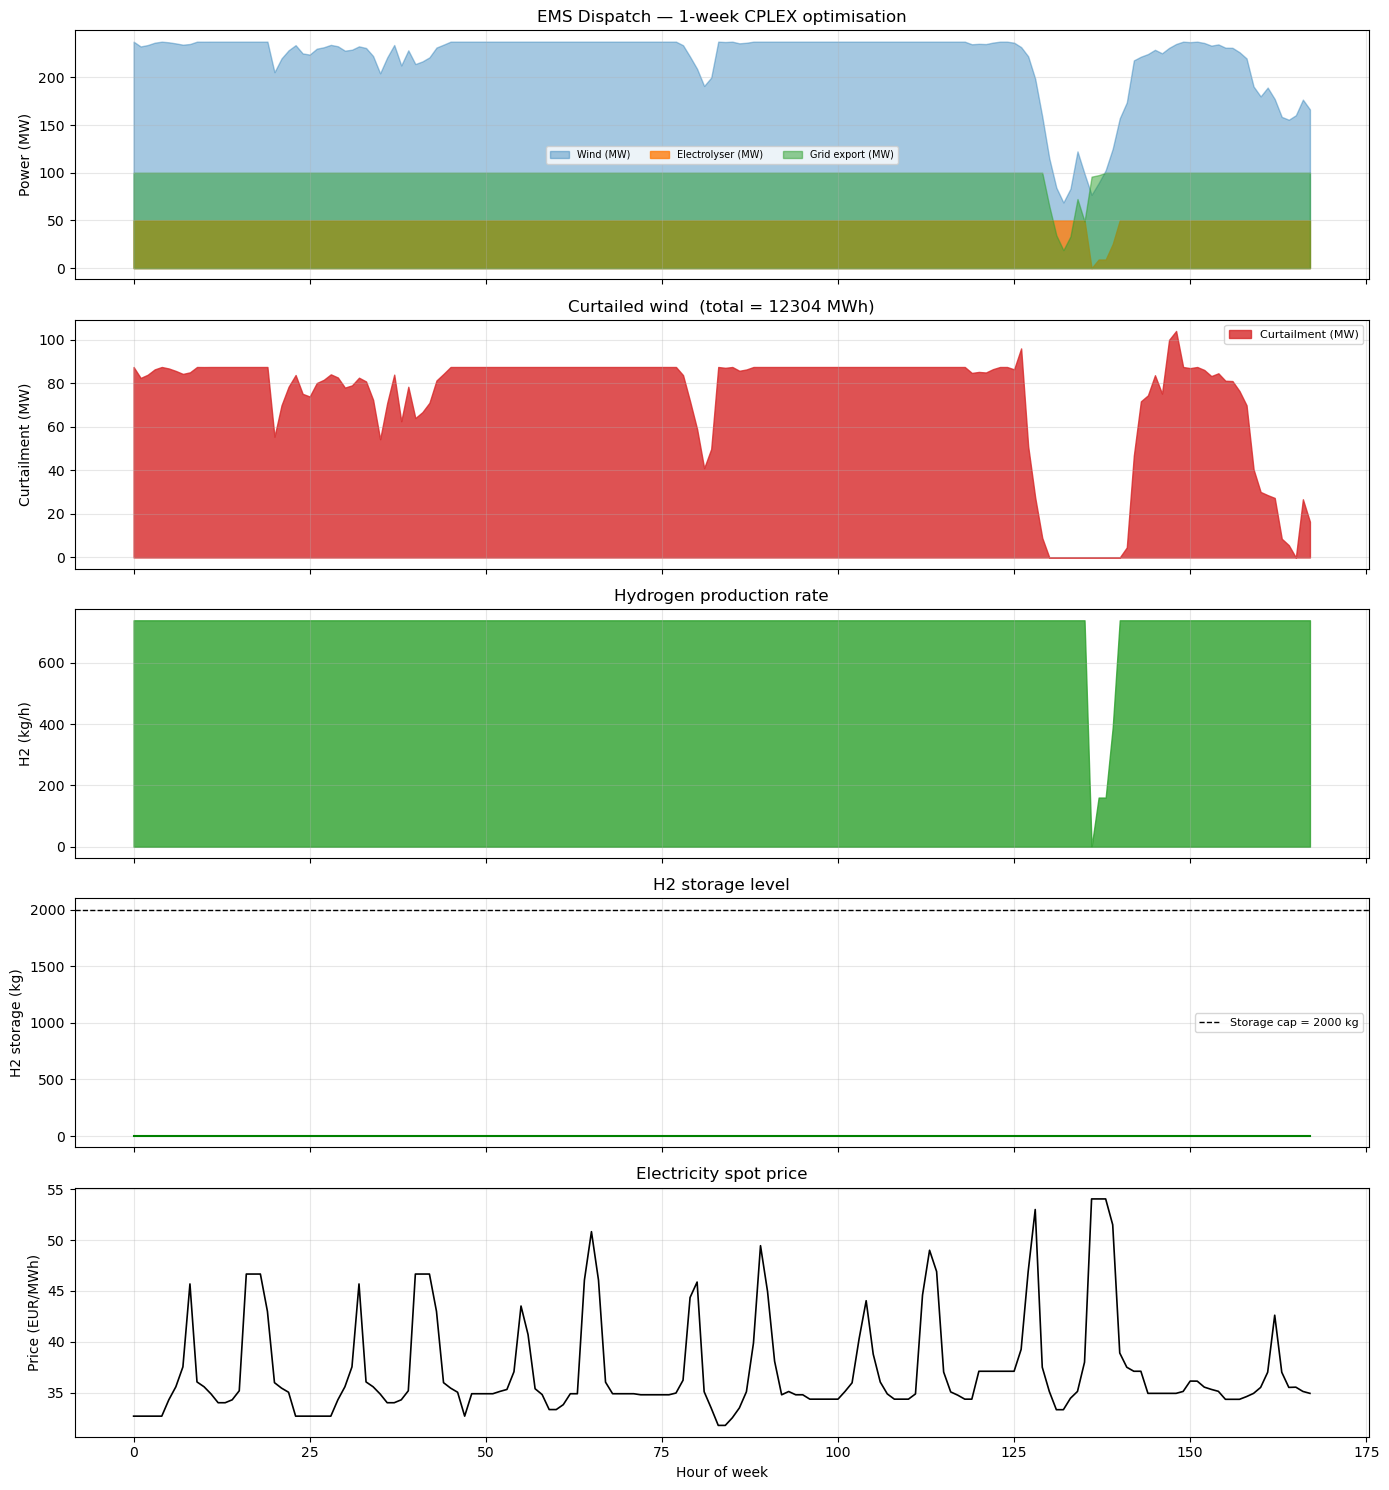

Week electricity revenue : EUR 613,661
Week H2 revenue          : EUR 608,637  (121727 kg sold)
Curtailment              : 12304 MWh


In [4]:
N_week = 168
idx_week = weather.index[:N_week]

def make_series(arr, idx):
    return pd.Series(arr, index=idx)

wind_ts_w  = make_series(wind_t[:N_week], idx_week)
solar_ts_w = make_series(np.zeros(N_week), idx_week)
price_ts_w = make_series(weather.Price.values[:N_week], idx_week)
E_batt_w   = make_series(np.full(N_week, 50.0), idx_week)
demand_w   = make_series(np.full(N_week, 1e3), idx_week)   # unlimited demand
H2stor_w   = make_series(np.full(N_week, HSS_kg), idx_week)

print('Running CPLEX EMS for 1 week (168 h)...')
(P_HPP, P_curt, P_cd, P_ptg, _, E_SOC,
 m_H2, m_off, LoS_H2, _) = ems_cplex_P2X(
    wind_ts=wind_ts_w, solar_ts=solar_ts_w, price_ts=price_ts_w,
    P_batt_MW=20.0, E_batt_MWh_t=E_batt_w,
    hpp_grid_connection=100, battery_depth_of_discharge=0.9,
    charge_efficiency=0.95, price_H2=5.0, ptg_MW=ptg_MW, HSS_kg=HSS_kg,
    storage_eff=0.9, hhv=hhv, m_H2_demand_ts=demand_w,
    H2_storage_t=H2stor_w, penalty_factor_H2=0.0,
    eff_curve=pem_prod[:-1], min_power_standby=0.0, batch_size=62,  # Community Edition: max ~62 h per batch (< 1000 vars)
    electrolyzer_eff_curve_type='production')
print('Done.')

hrs = np.arange(N_week)
fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)

axes[0].fill_between(hrs, wind_ts_w.values, alpha=0.4, color='tab:blue', label='Wind (MW)')
axes[0].fill_between(hrs, P_ptg, alpha=0.8, color='tab:orange', label='Electrolyser (MW)')
axes[0].fill_between(hrs, P_HPP, alpha=0.5, color='tab:green',  label='Grid export (MW)')
axes[0].set_ylabel('Power (MW)'); axes[0].legend(fontsize=7, ncol=3); axes[0].grid(alpha=0.3)
axes[0].set_title('EMS Dispatch — 1-week CPLEX optimisation')

axes[1].fill_between(hrs, P_curt, color='tab:red', alpha=0.8, label='Curtailment (MW)')
axes[1].set_ylabel('Curtailment (MW)'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set_title(f'Curtailed wind  (total = {P_curt.sum():.0f} MWh)')

axes[2].fill_between(hrs, m_H2, color='tab:green', alpha=0.8)
axes[2].set_ylabel('H2 (kg/h)'); axes[2].grid(alpha=0.3)
axes[2].set_title('Hydrogen production rate')

axes[3].plot(hrs, LoS_H2, 'g-', lw=1.5)
axes[3].axhline(HSS_kg, color='k', ls='--', lw=1, label=f'Storage cap = {HSS_kg:.0f} kg')
axes[3].set_ylabel('H2 storage (kg)'); axes[3].legend(fontsize=8); axes[3].grid(alpha=0.3)
axes[3].set_title('H2 storage level')

axes[4].plot(hrs, price_ts_w.values, 'k-', lw=1.2)
axes[4].set_ylabel('Price (EUR/MWh)'); axes[4].set_xlabel('Hour of week'); axes[4].grid(alpha=0.3)
axes[4].set_title('Electricity spot price')

plt.tight_layout(); plt.show()

rev_elec = (price_ts_w.values * P_HPP).sum()
rev_H2   = 5.0 * m_off.sum()
print(f'Week electricity revenue : EUR {rev_elec:,.0f}')
print(f'Week H2 revenue          : EUR {rev_H2:,.0f}  ({m_off.sum():.0f} kg sold)')
print(f'Curtailment              : {P_curt.sum():.0f} MWh')

## Capability 4 — Cost Model: CAPEX / OPEX Breakdown

The `ptg_cost` model separates costs into three components:

| Component | Driver | Formula |
|---|---|---|
| Electrolyser CAPEX | `ptg_MW` | `ptg_MW x (capex + pe_cost)` |
| H2 storage CAPEX | `HSS_kg` | `HSS_kg x storage_capex` |
| Electrolyser OPEX | `ptg_MW` | `ptg_MW x opex_yr` |
| Storage OPEX | `HSS_kg` | `HSS_kg x storage_opex_yr` |
| Water cost | H2 produced | `annual_H2 x water_consumption x (wc + wtc) / 1000` |

**LCOH** (EUR/kg) = (CAPEX / life_y + OPEX + water_cost) / annual_H2_kg

CAPEX         : EUR 40.6 M
OPEX/yr       : EUR 806 k/yr
Water cost/yr : EUR 305 k/yr
Annual H2     : 5410 tonnes/yr
LCOH          : EUR 0.51/kg


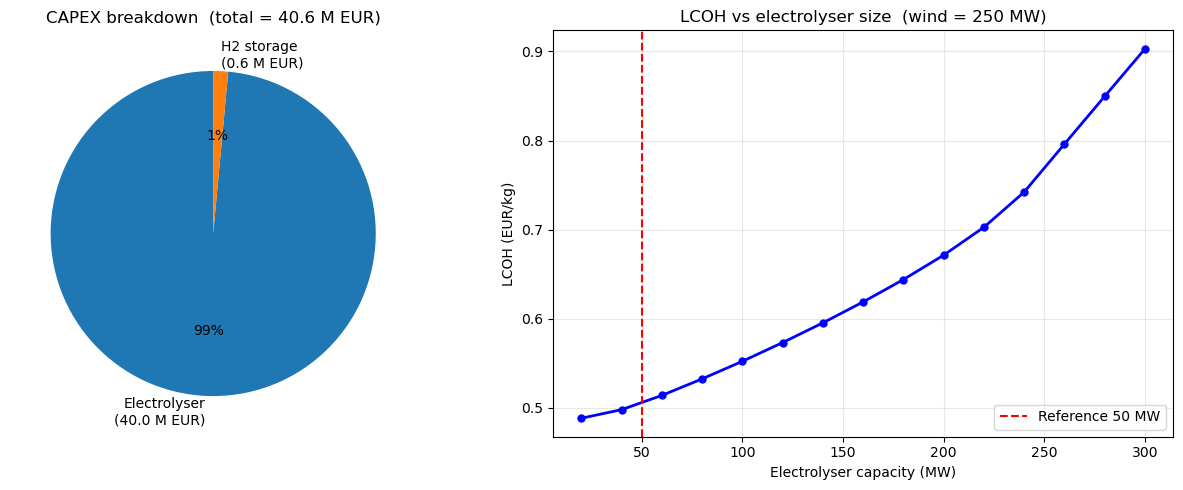

Minimum LCOH 0.49 EUR/kg at 20 MW


In [5]:
# Instantiate cost model with typical 2024 PEM cost assumptions
cost_model = ptg_cost(
    electrolyzer_capex_cost=800_000,          # EUR/MW -- electrolyser stack CAPEX
    electrolyzer_opex_cost=16_000,            # EUR/MW/yr -- annual O&M
    electrolyzer_power_electronics_cost=0,    # EUR/MW -- power electronics (included in capex)
    water_cost=4,                             # EUR/m3 -- feedwater purchase
    water_treatment_cost=2,                   # EUR/m3 -- deionisation treatment
    water_consumption=9.4,                    # kg water per kg H2 (electrolysis stoichiometry)
    storage_capex_cost=300,                   # EUR/kg H2 -- pressure vessel CAPEX
    storage_opex_cost=3,                      # EUR/kg/yr -- storage maintenance
    transportation_cost=5,                    # EUR/kg/km -- delivery cost
    transportation_distance=0,               # km -- 0 = on-site use, no transport cost
    N_time=8760, life_y=25,                  # hourly timesteps, 25-year project life
)

# Compute CAPEX [EUR], annual OPEX [EUR/yr], annual water cost [EUR/yr]
CAPEX, OPEX, water = cost_model.compute(ptg_MW, HSS_kg, pd.Series(m_H2_t))
annual_H2_t = pd.Series(m_H2_t).mean() * 8760 / 1000  # annual H2 [tonnes/yr]
# LCOH [EUR/kg] = (annualised CAPEX + OPEX + water) / annual_H2_kg
LCOH = (CAPEX / 25 + OPEX + water) / (annual_H2_t * 1000)

print(f'CAPEX         : EUR {CAPEX/1e6:.1f} M')
print(f'OPEX/yr       : EUR {OPEX/1e3:.0f} k/yr')
print(f'Water cost/yr : EUR {water/1e3:.0f} k/yr')
print(f'Annual H2     : {annual_H2_t:.0f} tonnes/yr')
print(f'LCOH          : EUR {LCOH:.2f}/kg')

elz_capex  = ptg_MW * 800_000   # electrolyser CAPEX component [EUR]
stor_capex = HSS_kg * 300        # storage CAPEX component [EUR]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: CAPEX split between electrolyser and storage
axes[0].pie([elz_capex, stor_capex],
            labels=[f'Electrolyser\n({elz_capex/1e6:.1f} M EUR)',
                    f'H2 storage\n({stor_capex/1e6:.1f} M EUR)'],
            colors=['tab:blue', 'tab:orange'], autopct='%1.0f%%', startangle=90)
axes[0].set_title(f'CAPEX breakdown  (total = {(elz_capex+stor_capex)/1e6:.1f} M EUR)')

# Right: LCOH vs electrolyser size -- find optimal sizing vs wind farm
sizes = np.arange(20, 301, 20)  # sweep 20 to 300 MW in 20 MW steps
lcohs = []
for sz in sizes:
    P_in_sz = np.minimum(wind_t, sz)           # greedy dispatch for this size
    load_sz = P_in_sz / sz                      # normalised load fraction
    m_sz = np.interp(load_sz, pem_prod[:-1, 0], pem_prod[:-1, 1], left=0, right=0) * sz
    ann_sz = m_sz.mean() * 8760 / 1000         # annual H2 [tonnes]
    C, O, W = cost_model.compute(sz, HSS_kg, pd.Series(m_sz))
    lcohs.append((C / 25 + O + W) / (ann_sz * 1000))  # LCOH [EUR/kg]

axes[1].plot(sizes, lcohs, 'b-o', ms=5, lw=2)
axes[1].axvline(ptg_MW, color='r', ls='--', lw=1.5, label=f'Reference {ptg_MW:.0f} MW')
axes[1].set_xlabel('Electrolyser capacity (MW)'); axes[1].set_ylabel('LCOH (EUR/kg)')
axes[1].set_title(f'LCOH vs electrolyser size  (wind = {wind_MW:.0f} MW)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Minimum LCOH {min(lcohs):.2f} EUR/kg at {sizes[int(np.argmin(lcohs))]:.0f} MW')

## Capability 5 — Annual Economics: Optimised H2 Yield & Revenue Split

Runs the full-year CPLEX EMS (8 760 h, batched in 62-h chunks) to get the **optimised** H2 production, then compares with the greedy baseline and computes a full economic summary.

Running CPLEX EMS for full year (8760 h, batch_size=62)...
Done.

--- Annual results (50 MW PEM, 250 MW wind, 2000 kg storage) ---
H2 production (optimised) : 4657 tonnes/yr
H2 production (greedy)    : 5410 tonnes/yr
Electrolyser capacity factor: 71.4 %
Electricity revenue/yr    : EUR 34.54 M
H2 revenue/yr             : EUR 23.28 M
LCOH (optimised dispatch) : EUR 0.58/kg


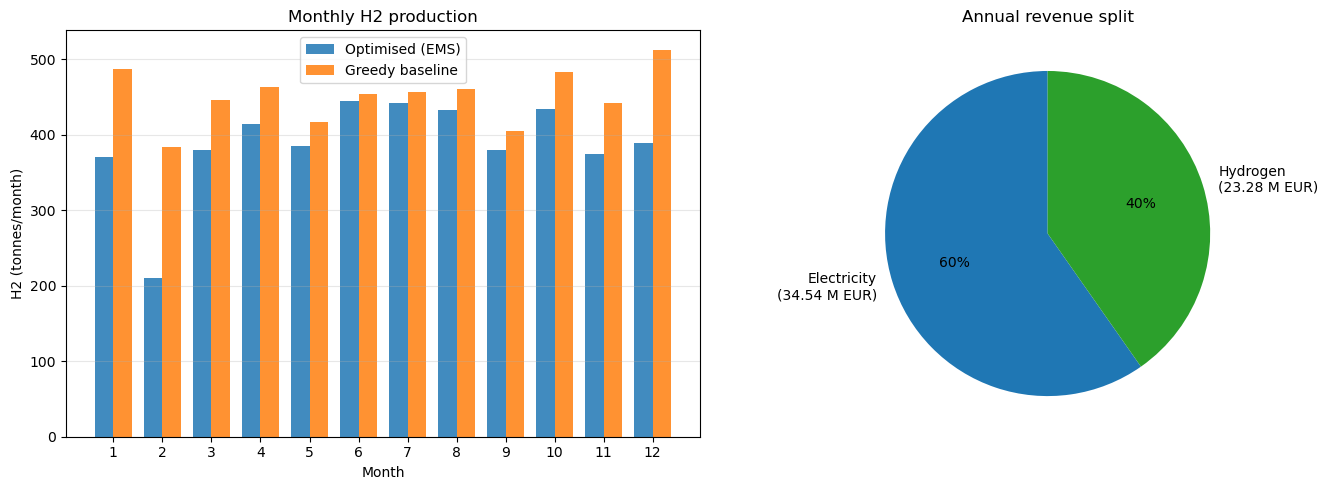

- Comparison: same inputs (50 MW PEM, 250 MW wind) ---
Metric                                 Optimised (EMS)       Greedy
-------------------------------------------------------------------
H2 production (tonnes/yr)                         4657         5410
Electricity revenue (M EUR)                      34.54        30.39
H2 revenue (M EUR)                               23.28        27.05
Total revenue (M EUR)                            57.82        57.44
LCOH (EUR/kg)                                     0.58         0.51


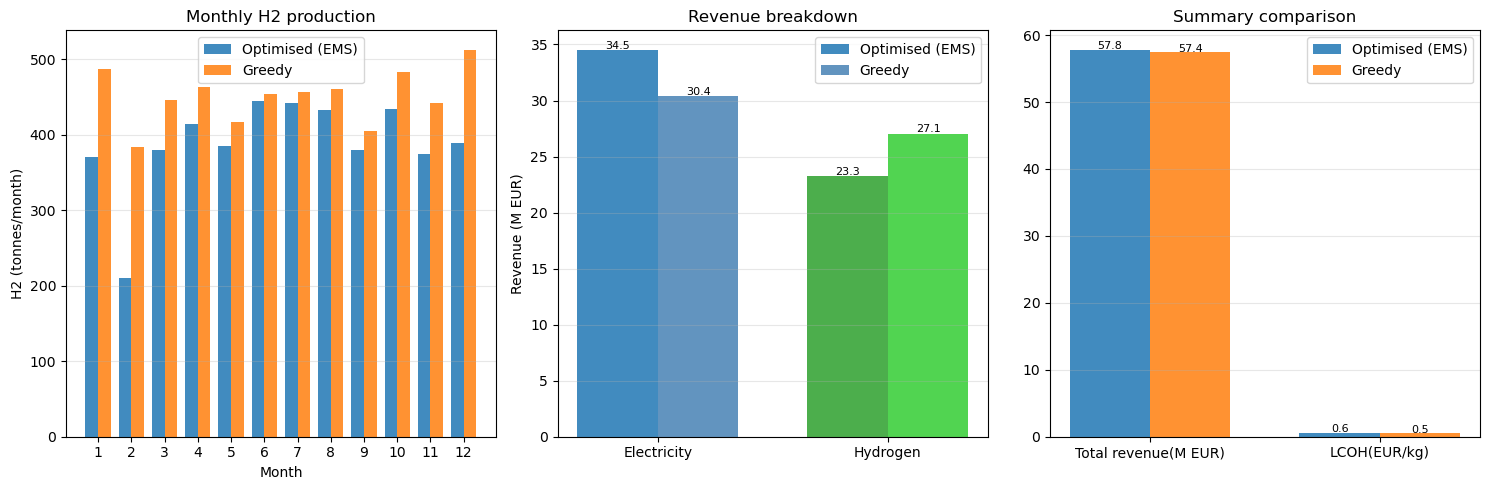

In [8]:
N_year = len(weather)

def make_series(arr, idx):
    return pd.Series(arr, index=idx)

wind_ts_yr  = make_series(wind_t, weather.index)
solar_ts_yr = make_series(np.zeros(N_year), weather.index)
price_ts_yr = make_series(weather.Price.values, weather.index)
E_batt_yr   = make_series(np.full(N_year, 50.0), weather.index)
demand_yr   = make_series(np.full(N_year, 1e6), weather.index)
H2stor_yr   = make_series(np.full(N_year, HSS_kg), weather.index)

print('Running CPLEX EMS for full year (8760 h, batch_size=62)...')
(P_HPP_yr, P_curt_yr, _, P_ptg_yr, _, _,
 m_H2_yr, m_off_yr, LoS_H2_yr, _) = ems_cplex_P2X(
    wind_ts=wind_ts_yr, solar_ts=solar_ts_yr, price_ts=price_ts_yr,
    P_batt_MW=20.0, E_batt_MWh_t=E_batt_yr,
    hpp_grid_connection=wind_MW, battery_depth_of_discharge=0.9,
    charge_efficiency=0.95, price_H2=5.0, ptg_MW=ptg_MW, HSS_kg=HSS_kg,
    storage_eff=0.9, hhv=hhv, m_H2_demand_ts=demand_yr,
    H2_storage_t=H2stor_yr, penalty_factor_H2=0.0,
    eff_curve=pem_prod[:-1], min_power_standby=0.0, batch_size=62,
    electrolyzer_eff_curve_type='production')
print('Done.')

ann_H2_opt   = m_off_yr.sum() / 1000
ann_H2_greed = m_H2_t.sum() / 1000
rev_elec_yr  = (price_ts_yr.values * P_HPP_yr).sum()
rev_H2_yr    = 5.0 * m_off_yr.sum()
cf_opt       = P_ptg_yr.mean() / ptg_MW * 100

CAPEX, OPEX, water = cost_model.compute(ptg_MW, HSS_kg, pd.Series(m_off_yr))
LCOH_opt = (CAPEX / 25 + OPEX + water) / (ann_H2_opt * 1000)

print(f'\n--- Annual results ({ptg_MW:.0f} MW PEM, {wind_MW:.0f} MW wind, {HSS_kg:.0f} kg storage) ---')
print(f'H2 production (optimised) : {ann_H2_opt:.0f} tonnes/yr')
print(f'H2 production (greedy)    : {ann_H2_greed:.0f} tonnes/yr')
print(f'Electrolyser capacity factor: {cf_opt:.1f} %')
print(f'Electricity revenue/yr    : EUR {rev_elec_yr/1e6:.2f} M')
print(f'H2 revenue/yr             : EUR {rev_H2_yr/1e6:.2f} M')
print(f'LCOH (optimised dispatch) : EUR {LCOH_opt:.2f}/kg')

mo_opt   = pd.Series(m_H2_yr, index=weather.index).resample('ME').sum() / 1000
mo_greed = pd.Series(m_H2_t,  index=weather.index).resample('ME').sum() / 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(1, 13); w = 0.38
axes[0].bar(x - w/2, mo_opt.values,   w, label='Optimised (EMS)', color='tab:blue',   alpha=0.85)
axes[0].bar(x + w/2, mo_greed.values, w, label='Greedy baseline', color='tab:orange', alpha=0.85)
axes[0].set_xlabel('Month'); axes[0].set_ylabel('H2 (tonnes/month)')
axes[0].set_title('Monthly H2 production'); axes[0].set_xticks(x)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].pie([rev_elec_yr, rev_H2_yr],
            labels=[f'Electricity\n({rev_elec_yr/1e6:.2f} M EUR)',
                    f'Hydrogen\n({rev_H2_yr/1e6:.2f} M EUR)'],
            colors=['tab:blue', 'tab:green'], autopct='%1.0f%%', startangle=90)
axes[1].set_title('Annual revenue split')

plt.tight_layout(); plt.show()

# ── Greedy with same inputs (electrolyser first, surplus to grid) ─────────
P_in_g    = np.minimum(wind_t, ptg_MW)
load_g    = P_in_g / ptg_MW
m_H2_g    = np.interp(load_g, pem_prod[:-1, 0], pem_prod[:-1, 1], left=0, right=0) * ptg_MW
P_surp_g  = np.clip(wind_t - ptg_MW, 0, wind_MW)   # surplus exported to grid
rev_elec_g = (price_ts_yr.values * P_surp_g).sum()
rev_H2_g   = 5.0 * m_H2_g.sum()
ann_H2_g   = m_H2_g.sum() / 1000
CAPEX_g, OPEX_g, water_g = cost_model.compute(ptg_MW, HSS_kg, pd.Series(m_H2_g))
LCOH_g = (CAPEX_g / 25 + OPEX_g + water_g) / (ann_H2_g * 1000)

mo_opt_2   = pd.Series(m_H2_yr, index=weather.index).resample('ME').sum() / 1000
mo_greed_2 = pd.Series(m_H2_g,  index=weather.index).resample('ME').sum() / 1000

print(f'- Comparison: same inputs ({ptg_MW:.0f} MW PEM, {wind_MW:.0f} MW wind) ---')
print(f'{"Metric":<35} {"Optimised (EMS)":>18} {"Greedy":>12}')
print('-' * 67)
print(f'{"H2 production (tonnes/yr)":<35} {ann_H2_opt:>18.0f} {ann_H2_g:>12.0f}')
print(f'{"Electricity revenue (M EUR)":<35} {rev_elec_yr/1e6:>18.2f} {rev_elec_g/1e6:>12.2f}')
print(f'{"H2 revenue (M EUR)":<35} {rev_H2_yr/1e6:>18.2f} {rev_H2_g/1e6:>12.2f}')
print(f'{"Total revenue (M EUR)":<35} {(rev_elec_yr+rev_H2_yr)/1e6:>18.2f} {(rev_elec_g+rev_H2_g)/1e6:>12.2f}')
print(f'{"LCOH (EUR/kg)":<35} {LCOH_opt:>18.2f} {LCOH_g:>12.2f}')

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

# Monthly H2
x = np.arange(1, 13); w = 0.38
axes2[0].bar(x - w/2, mo_opt_2.values,   w, label='Optimised (EMS)', color='tab:blue',   alpha=0.85)
axes2[0].bar(x + w/2, mo_greed_2.values, w, label='Greedy',          color='tab:orange', alpha=0.85)
axes2[0].set_xlabel('Month'); axes2[0].set_ylabel('H2 (tonnes/month)')
axes2[0].set_title('Monthly H2 production')
axes2[0].set_xticks(x); axes2[0].legend(); axes2[0].grid(axis='y', alpha=0.3)

# Revenue breakdown
cats  = ['Electricity', 'Hydrogen']
opt_r = [rev_elec_yr/1e6, rev_H2_yr/1e6]
grd_r = [rev_elec_g/1e6,  rev_H2_g/1e6]
xb = np.arange(len(cats)); w2 = 0.35
bars_o = axes2[1].bar(xb - w2/2, opt_r, w2, color=['tab:blue', 'tab:green'], alpha=0.85, label='Optimised (EMS)')
bars_g = axes2[1].bar(xb + w2/2, grd_r, w2, color=['steelblue', 'limegreen'], alpha=0.85, label='Greedy')
axes2[1].set_xticks(xb); axes2[1].set_xticklabels(cats)
axes2[1].set_ylabel('Revenue (M EUR)'); axes2[1].set_title('Revenue breakdown')
axes2[1].legend(); axes2[1].grid(axis='y', alpha=0.3)
for bar in bars_o: axes2[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{bar.get_height():.1f}', ha='center', fontsize=8)
for bar in bars_g: axes2[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{bar.get_height():.1f}', ha='center', fontsize=8)

# Total revenue (left) and LCOH (right) on separate y-axes
xc = np.array([0]); w2 = 0.35
b1 = axes2[2].bar(xc - w2/2, [(rev_elec_yr+rev_H2_yr)/1e6], w2, label='Optimised (EMS)', color='tab:blue',   alpha=0.85)
b2 = axes2[2].bar(xc + w2/2, [(rev_elec_g +rev_H2_g) /1e6], w2, label='Greedy',          color='tab:orange', alpha=0.85)
axes2[2].set_ylabel('Total revenue (M EUR)')
axes2[2].legend(loc='upper left', fontsize=8); axes2[2].grid(axis='y', alpha=0.3)
for bar in [b1[0], b2[0]]: axes2[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')

ax_lcoh = axes2[2].twinx()
xd = np.array([1])
ax_lcoh.bar(xd - w2/2, [LCOH_opt], w2, color='tab:blue',   alpha=0.55)
ax_lcoh.bar(xd + w2/2, [LCOH_g],   w2, color='tab:orange', alpha=0.55)
ax_lcoh.set_ylabel('LCOH (EUR/kg)', color='tab:red')
ax_lcoh.set_ylim(0, max(LCOH_opt, LCOH_g) * 3)
ax_lcoh.text(xd[0]-w2/2, LCOH_opt*1.05, f'{LCOH_opt:.2f}', ha='center', fontsize=9, fontweight='bold')
ax_lcoh.text(xd[0]+w2/2, LCOH_g  *1.05, f'{LCOH_g:.2f}',   ha='center', fontsize=9, fontweight='bold')
axes2[2].set_xlim(-0.6, 1.6)
axes2[2].set_xticks([0, 1]); axes2[2].set_xticklabels(['Total revenue
(M EUR)', 'LCOH
(EUR/kg)'])
axes2[2].set_title('Summary comparison')

plt.tight_layout(); plt.show()


## Capability 6 — Electrolyser Degradation over Lifetime

The degradation model (`ems_long_term_operation_p2x`) applies **two compounding effects** over the plant lifetime:

| Effect | Driver | Formula |
|---|---|---|
| Wind power reduction | Time (turbine ageing) | `wind_t_yr = wind_t x (1 - wind_deg_yr)` |
| Electrolyser efficiency loss | Time (PEM membrane wear) | `m_H2_yr = (1 - ptg_deg_yr) x interp(p_ptg, H2_curve)` |

Typical PEM degradation: **0.5–1 %/yr** → **12.5–25 % loss** over 25 years.
Wind degradation: **0.4 %/yr** → **10 % loss** over 25 years.

The degradation factor is interpolated from `(ptg_deg_yr, ptg_deg_profile)` using `np.interp` — any profile shape is supported.

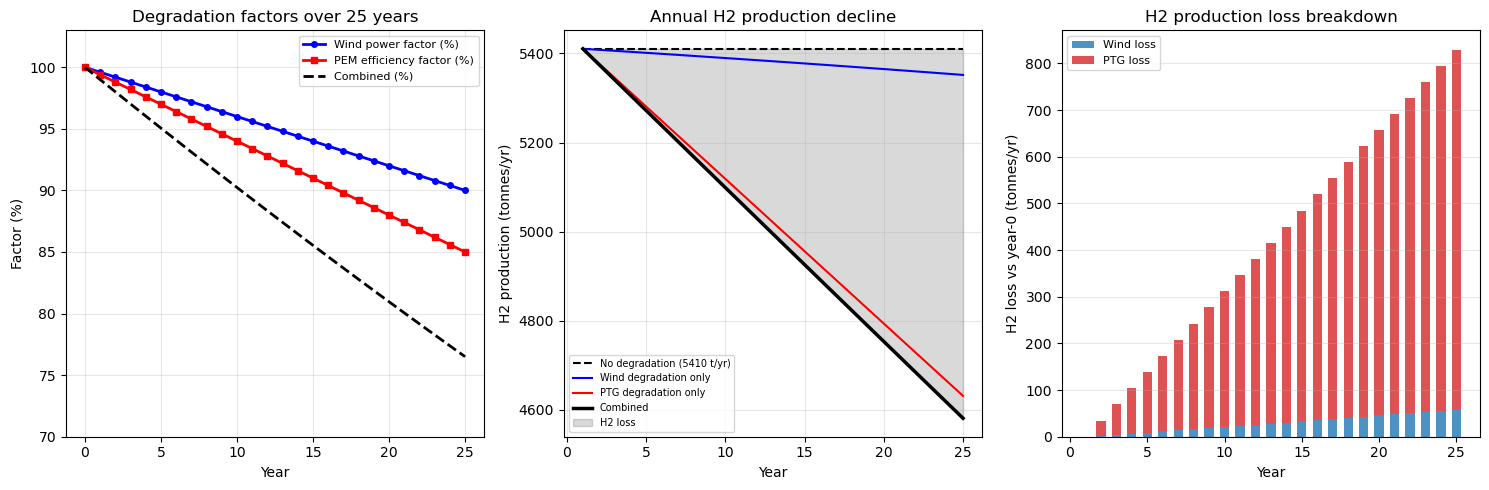

Lifetime H2 no degradation  : 135,262 tonnes
Lifetime H2 with degradation: 124,882 tonnes
Total H2 loss               : 10,380 t  (7.7 %)
  of which wind degradation : 711 t  (7 %)
  of which PTG degradation  : 9,669 t  (93 %)
LCOH without degradation    : EUR 0.50/kg
LCOH with degradation       : EUR 0.54/kg  (+8.3 %)


In [7]:
# Degradation parameters: 10% wind loss, 15% PEM efficiency loss, both linear over 25 years
life_y_deg  = 25
wind_deg_yr = [0, 25];  wind_deg  = [0.0, 0.10]   # wind: 10% cumulative power loss
ptg_deg_yr  = [0, 25];  ptg_deg_p = [0.0, 0.15]   # PEM: 15% cumulative efficiency loss
t_years = np.linspace(0, life_y_deg, life_y_deg + 1)  # [0, 1, 2, ..., 25]

# Remaining performance factor for each year (1.0=new, 0.0=dead)
wind_factor = 1 - np.interp(t_years, wind_deg_yr, wind_deg)   # e.g. year 10 -> 0.96
ptg_factor  = 1 - np.interp(t_years, ptg_deg_yr,  ptg_deg_p)  # e.g. year 10 -> 0.94

N_annual = len(weather)  # 8760 hours per year

def annual_H2_tonnes(wind_scale, ptg_scale):
    # Scale wind output by wind_scale (blade roughness -> less power at same wind speed)
    w = get_wind_ts(ws_ref, pc_ref * wind_MW * wind_scale, wst, wpp_efficiency=0.95)
    p_in = np.minimum(w, ptg_MW)   # greedy: electrolyser first, capped at rated
    load  = p_in / ptg_MW          # normalised load 0-1
    # Look up H2 from PEM curve, then apply ptg_scale (membrane wear -> less H2 per kWh)
    m_h2  = np.interp(load, pem_prod[:-1, 0], pem_prod[:-1, 1], left=0, right=0) * ptg_MW
    return ptg_scale * m_h2.sum() / 1000  # annual H2 [tonnes/yr]

H2_base      = annual_H2_tonnes(1.0, 1.0)                         # year-0 reference
H2_wind_only = [annual_H2_tonnes(wind_factor[yr], 1.0)             for yr in range(life_y_deg)]
H2_ptg_only  = [annual_H2_tonnes(1.0,             ptg_factor[yr])  for yr in range(life_y_deg)]
H2_combined  = [annual_H2_tonnes(wind_factor[yr],  ptg_factor[yr]) for yr in range(life_y_deg)]
years = np.arange(1, life_y_deg + 1)  # x-axis 1..25

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: how much performance (%) remains each year for each component
axes[0].plot(t_years, wind_factor * 100, 'b-o', ms=4, lw=2, label='Wind power factor (%)')
axes[0].plot(t_years, ptg_factor  * 100, 'r-s', ms=4, lw=2, label='PEM efficiency factor (%)')
# Combined = wind_factor * ptg_factor (multiplicative, not additive)
axes[0].plot(t_years, wind_factor * ptg_factor * 100, 'k--', lw=2, label='Combined (%)')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Factor (%)')
axes[0].set_title('Degradation factors over 25 years')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3); axes[0].set_ylim(70, 103)

# Middle: annual H2 [t/yr] for 4 scenarios -- isolates contribution of each effect
axes[1].plot(years, [H2_base]*life_y_deg, 'k--', lw=1.5, label=f'No degradation ({H2_base:.0f} t/yr)')
axes[1].plot(years, H2_wind_only,  'b-',  lw=1.5, label='Wind degradation only')
axes[1].plot(years, H2_ptg_only,   'r-',  lw=1.5, label='PTG degradation only')
axes[1].plot(years, H2_combined,   'k-',  lw=2.5, label='Combined')
# Grey area = total H2 lost vs no-degradation baseline
axes[1].fill_between(years, H2_combined, H2_base, alpha=0.15, color='k', label='H2 loss')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('H2 production (tonnes/yr)')
axes[1].set_title('Annual H2 production decline')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

# Right: stacked bars show which source dominates the loss each year
loss_wind = H2_base - np.array(H2_wind_only)           # H2 lost due to wind ageing
loss_ptg  = np.array(H2_wind_only) - np.array(H2_combined)  # additional H2 lost from PEM wear
axes[2].bar(years, loss_wind, 0.6, label='Wind loss', color='tab:blue',  alpha=0.8)
axes[2].bar(years, loss_ptg,  0.6, bottom=loss_wind, label='PTG loss', color='tab:red', alpha=0.8)
axes[2].set_xlabel('Year'); axes[2].set_ylabel('H2 loss vs year-0 (tonnes/yr)')
axes[2].set_title('H2 production loss breakdown')
axes[2].legend(fontsize=8); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

# Lifetime totals
lf_nodeg = H2_base * life_y_deg   # total H2 if no degradation [tonnes]
lf_comb  = sum(H2_combined)        # actual lifetime H2 [tonnes]
loss_pct = (1 - lf_comb / lf_nodeg) * 100
print(f'Lifetime H2 no degradation  : {lf_nodeg:,.0f} tonnes')
print(f'Lifetime H2 with degradation: {lf_comb:,.0f} tonnes')
print(f'Total H2 loss               : {lf_nodeg - lf_comb:,.0f} t  ({loss_pct:.1f} %)')
tot_loss = lf_nodeg - lf_comb
print(f'  of which wind degradation : {sum(loss_wind):,.0f} t  ({sum(loss_wind)/tot_loss*100:.0f} %)')
print(f'  of which PTG degradation  : {sum(loss_ptg):,.0f} t  ({sum(loss_ptg)/tot_loss*100:.0f} %)')

# LCOH impact: same fixed costs / fewer kg H2 -> higher LCOH with degradation
CAPEX, OPEX, water = cost_model.compute(ptg_MW, HSS_kg, pd.Series(np.array(H2_combined)*1000/8760))
annual_avg = lf_comb / life_y_deg   # average annual H2 over lifetime [tonnes/yr]
LCOH_deg  = (CAPEX / life_y_deg + OPEX + water) / (annual_avg * 1000)
LCOH_nodeg = (CAPEX / life_y_deg + OPEX + water) / (H2_base * 1000)
print(f'LCOH without degradation    : EUR {LCOH_nodeg:.2f}/kg')
print(f'LCOH with degradation       : EUR {LCOH_deg:.2f}/kg  (+{(LCOH_deg/LCOH_nodeg-1)*100:.1f} %)')